### Perceptron Trick

In [3]:
from sklearn.datasets import make_classification
import numpy as np

c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import csr_matrix, issparse


In [4]:
X, y= make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

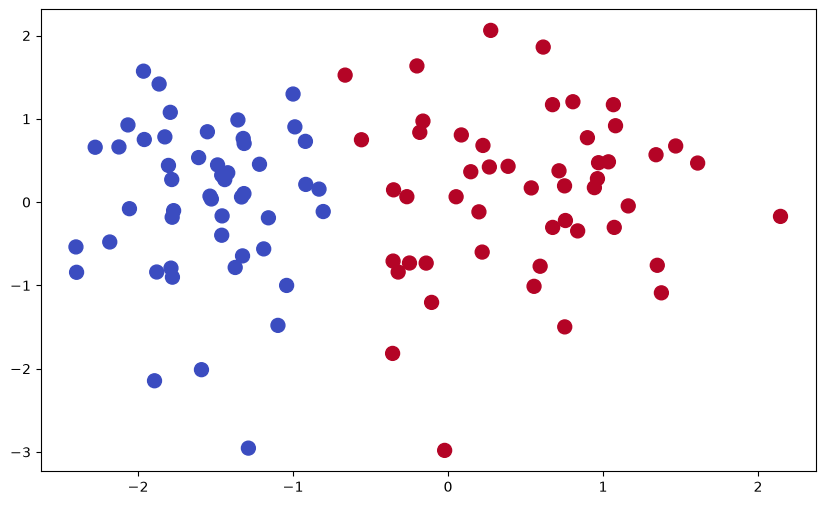

In [5]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(10, 6))
plt.scatter(X[:,0],X[:,1],cmap="coolwarm",s=100, c=y)

In [6]:
def perceptron(X, y):

    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr = 1
    epoch=1000

    for i in range(epoch):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(X[j],weights))
        weights=weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [7]:
def step(z):
    return 1 if z>0 else 0

In [8]:
intercept_, coef_ = perceptron(X, y)

In [9]:
print(coef_)
print(intercept_)

[4.95200837 0.62289011]
4.0


### Loss Function of the Perceptron

In [10]:
X_new, y_new = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1, hypercube=False,class_sep=15, random_state=41)

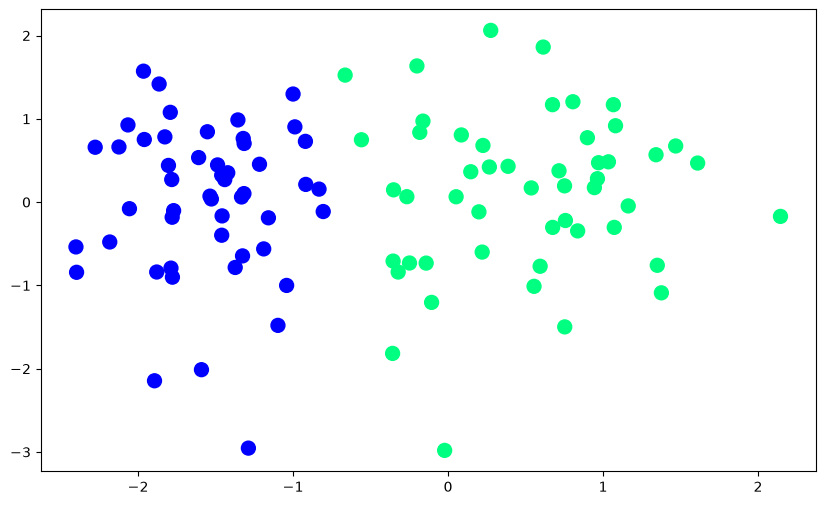

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],cmap="winter",c=y_new, s=100)

In [12]:
def perceptron(X, y):

    w1=w2=b=1
    lr=0.1
    epoch=1000

    for i in range(epoch):
        for j in range(X.shape[0]):
            z=w1*X[j][0] + w2*X[j][1] + b

            if z*y[j]<0:
                w1=w1 + lr * y[j]* X[j][0]
                w2=w2 + lr * y[j]* X[j][1]
                b=b + lr * y[j]

    return w1, w2, b

In [13]:
w1, w2, b = perceptron(X_new, y_new)

In [16]:
b

np.float64(1.3000000000000003)

In [17]:
m = -(w1/w2)
c = -(b/w2)
print(m, c)

-4.531321834268464 -5.851870329508209


(-3.0, 2.0)

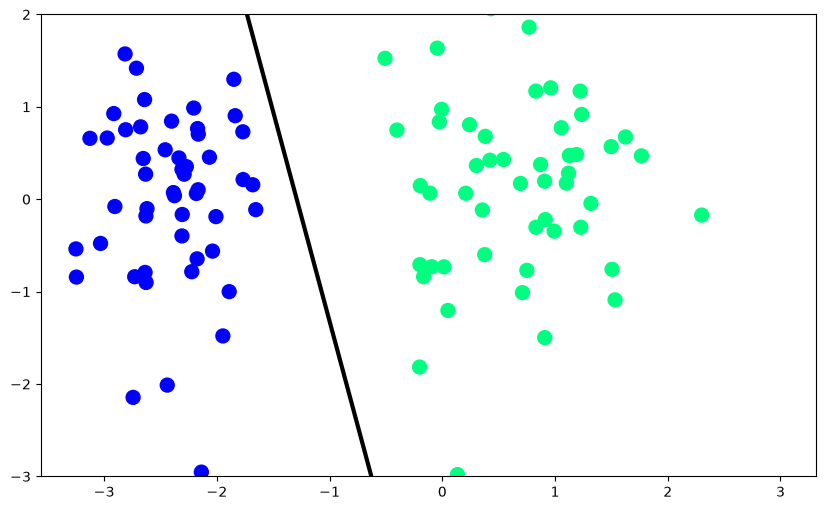

In [18]:
x_input = np.linspace(-3, 3 ,100)
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='black', linewidth= 3)
plt.scatter(X_new[:,0], X_new[:,1], cmap="winter", c=y, s=100)
plt.ylim(-3, 2)